# Week 10 실습: SGD와 Mini-batch SGD

GD, SGD, Mini-batch SGD를 같은 최소제곱 문제와 비선형 목적함수에 적용해 비교합니다.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

## 1. Synthetic least squares data

Normal equation theta = [1.01331581 1.99786249]


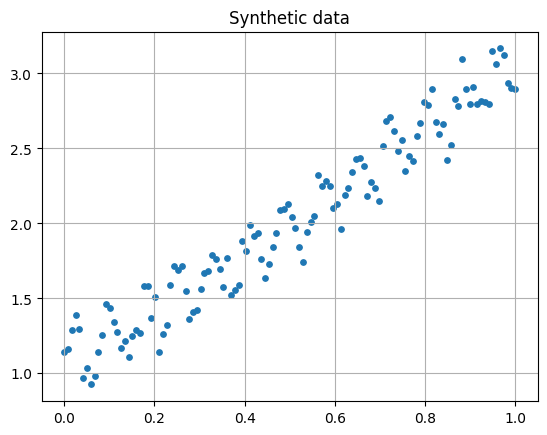

In [9]:
N = 120
x = np.linspace(0, 1, N)
y = 2*x + 1 + 0.18*np.sin(80*x) + 0.08*np.random.randn(N)
A = np.c_[np.ones(N), x]

def mse(theta, A=A, y=y):
    r = A @ theta - y
    return np.mean(r*r)

def full_grad(theta, A=A, y=y):
    return 2/len(y) * A.T @ (A @ theta - y)

def batch_grad(theta, idx, A=A, y=y):
    Ab, yb = A[idx], y[idx]
    return 2/len(idx) * Ab.T @ (Ab @ theta - yb)

theta_ne = np.linalg.lstsq(A, y, rcond=None)[0]
print('Normal equation theta =', theta_ne)
plt.scatter(x, y, s=15)
plt.title('Synthetic data')
plt.grid(True)
plt.show()

## 2. GD, SGD, Mini-batch SGD 구현

In [10]:
def run_optimizer(method='gd', lr=0.1, epochs=80, batch_size=16, theta0=None):
    theta = np.zeros(2) if theta0 is None else theta0.astype(float).copy()
    hist = [theta.copy()]
    losses = [mse(theta)]
    N = len(y)
    for ep in range(epochs):
        if method == 'gd':
            theta -= lr * full_grad(theta)
        else:
            indices = np.random.permutation(N)
            bs = 1 if method == 'sgd' else batch_size
            for start in range(0, N, bs):
                idx = indices[start:start+bs]
                theta -= lr * batch_grad(theta, idx)
        hist.append(theta.copy())
        losses.append(mse(theta))
    return theta, np.array(hist), np.array(losses)

theta_gd, hist_gd, loss_gd = run_optimizer('gd', lr=0.25, epochs=80)
theta_sgd, hist_sgd, loss_sgd = run_optimizer('sgd', lr=0.04, epochs=80)
theta_mb, hist_mb, loss_mb = run_optimizer('minibatch', lr=0.08, epochs=80, batch_size=16)
print('GD:', theta_gd)
print('SGD:', theta_sgd)
print('Mini-batch:', theta_mb)

GD: [1.05325922 1.92331449]
SGD: [1.04088471 2.03401429]
Mini-batch: [1.00256236 1.99146293]


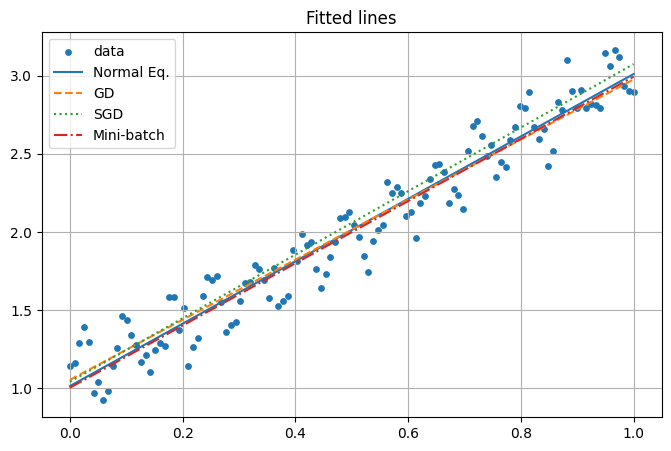

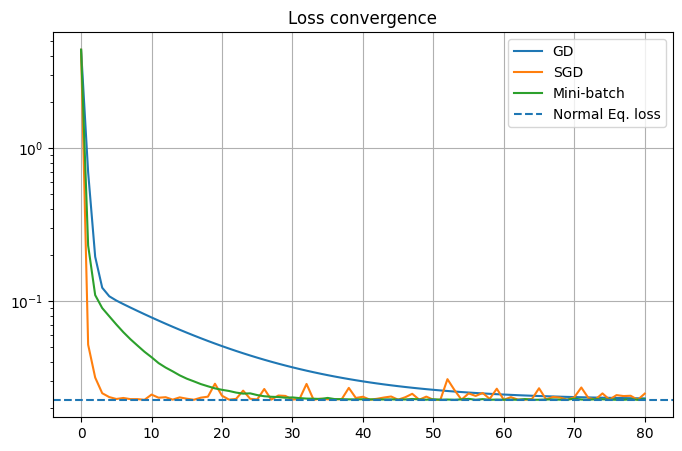

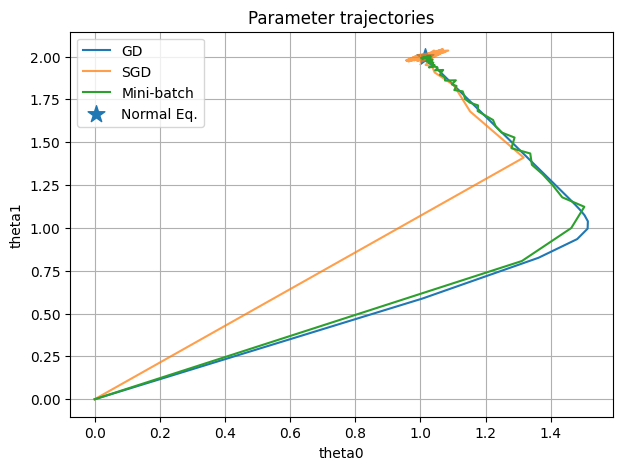

In [11]:
xx = np.linspace(0,1,200)
plt.figure(figsize=(8,5))
plt.scatter(x,y,s=15,label='data')
plt.plot(xx, theta_ne[0]+theta_ne[1]*xx, label='Normal Eq.')
plt.plot(xx, theta_gd[0]+theta_gd[1]*xx, '--', label='GD')
plt.plot(xx, theta_sgd[0]+theta_sgd[1]*xx, ':', label='SGD')
plt.plot(xx, theta_mb[0]+theta_mb[1]*xx, '-.', label='Mini-batch')
plt.legend(); plt.grid(True); plt.title('Fitted lines'); plt.show()

plt.figure(figsize=(8,5))
plt.plot(loss_gd,label='GD')
plt.plot(loss_sgd,label='SGD')
plt.plot(loss_mb,label='Mini-batch')
plt.axhline(mse(theta_ne), ls='--', label='Normal Eq. loss')
plt.yscale('log'); plt.legend(); plt.grid(True); plt.title('Loss convergence'); plt.show()

plt.figure(figsize=(7,5))
plt.plot(hist_gd[:,0], hist_gd[:,1], label='GD')
plt.plot(hist_sgd[:,0], hist_sgd[:,1], label='SGD', alpha=.75)
plt.plot(hist_mb[:,0], hist_mb[:,1], label='Mini-batch')
plt.scatter(theta_ne[0], theta_ne[1], marker='*', s=160, label='Normal Eq.')
plt.xlabel('theta0'); plt.ylabel('theta1'); plt.legend(); plt.grid(True); plt.title('Parameter trajectories'); plt.show()

## 3. Batch size 효과 실험

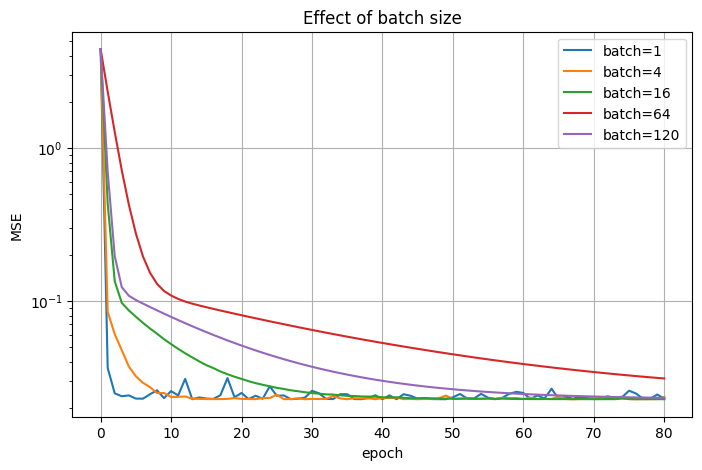

In [12]:
batch_sizes = [1, 4, 16, 64, len(y)]
plt.figure(figsize=(8,5))
for bs in batch_sizes:
    method = 'gd' if bs == len(y) else ('sgd' if bs == 1 else 'minibatch')
    _, _, losses = run_optimizer(method, lr=0.06 if bs < len(y) else 0.25, epochs=80, batch_size=bs)
    plt.plot(losses, label=f'batch={bs}')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True); plt.title('Effect of batch size'); plt.show()

## 4. Ill-conditioned quadratic: GD trajectory

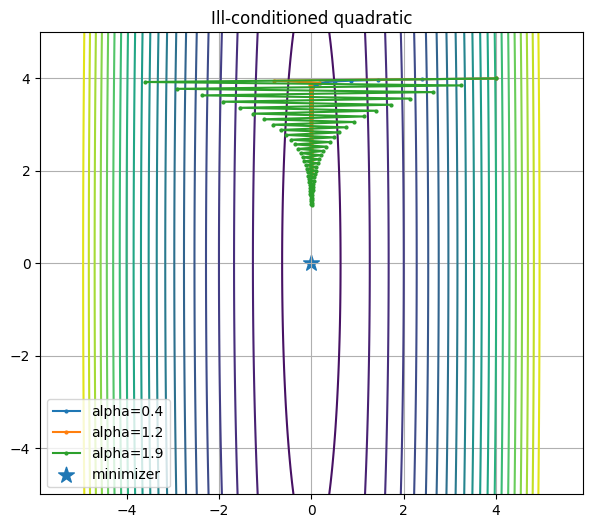

In [13]:
Q = np.diag([1.0, 0.01])
def f_quad(v): return 0.5 * (v @ Q @ v) + 1
def grad_quad(v): return Q @ v
def gd_quad(alpha, x0=np.array([4.,4.]), maxit=60):
    v = x0.copy(); pts = [v.copy()]
    for k in range(maxit):
        v = v - alpha * grad_quad(v)
        pts.append(v.copy())
    return np.array(pts)

X, Y = np.meshgrid(np.linspace(-5,5,300), np.linspace(-5,5,300))
Z = 0.5*(X**2 + 0.01*Y**2) + 1
plt.figure(figsize=(7,6))
plt.contour(X,Y,Z,levels=24)
for alpha in [0.4, 1.2, 1.9]:
    p = gd_quad(alpha)
    plt.plot(p[:,0], p[:,1], marker='o', ms=2, label=f'alpha={alpha}')
plt.scatter([0],[0],marker='*',s=140,label='minimizer')
plt.axis('equal'); plt.grid(True); plt.legend(); plt.title('Ill-conditioned quadratic'); plt.show()

## 5. Rosenbrock function

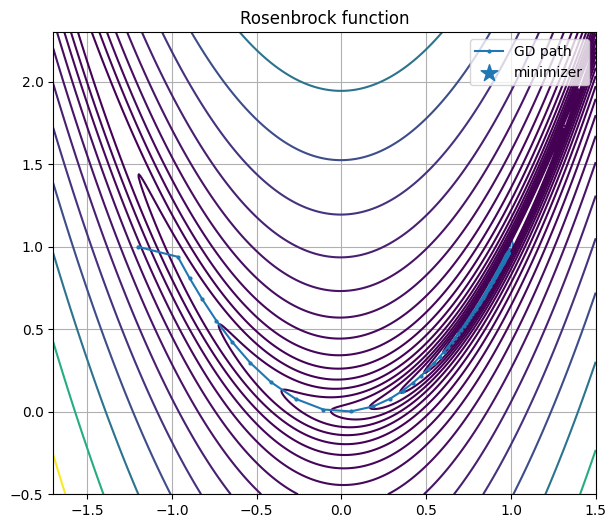

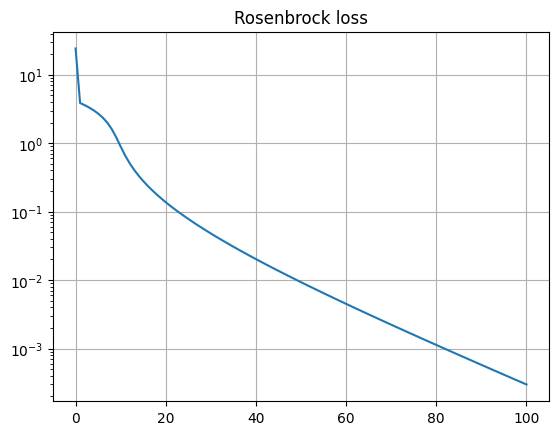

In [14]:
def rosen(v):
    x, y = v
    return 100*(y-x*x)**2 + (1-x)**2
def grad_rosen(v):
    x, y = v
    return np.array([-400*x*(y-x*x)-2*(1-x), 200*(y-x*x)])
def gd_rosen(alpha=1e-3, x0=np.array([-1.2,1.0]), maxit=8000):
    v = x0.copy(); pts=[]; losses=[]
    for k in range(maxit):
        if k % 80 == 0:
            pts.append(v.copy()); losses.append(rosen(v))
        v = v - alpha * grad_rosen(v)
    pts.append(v.copy()); losses.append(rosen(v))
    return np.array(pts), np.array(losses)

rx = np.linspace(-1.7,1.5,400); ry = np.linspace(-.5,2.3,400)
XX, YY = np.meshgrid(rx, ry); ZZ = 100*(YY-XX**2)**2 + (1-XX)**2
path, losses = gd_rosen()
plt.figure(figsize=(7,6))
plt.contour(XX, YY, ZZ, levels=np.logspace(-1,3,20))
plt.plot(path[:,0], path[:,1], marker='o', ms=2, label='GD path')
plt.scatter([1],[1],marker='*',s=160,label='minimizer')
plt.grid(True); plt.legend(); plt.title('Rosenbrock function'); plt.show()
plt.plot(losses); plt.yscale('log'); plt.grid(True); plt.title('Rosenbrock loss'); plt.show()

## 생각해 볼 질문
1. SGD의 loss curve가 더 흔들리는 이유는 무엇인가?
2. batch size가 커질수록 GD와 어떤 점이 비슷해지는가?
3. ill-conditioned quadratic에서 경로가 느리거나 지그재그가 되는 이유는 무엇인가?
4. Rosenbrock 함수에서 learning rate 선택이 어려운 이유는 무엇인가?